# **0 Install Library**

In [1]:
!pip install climada
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/

# **1.1 Using Random Exposure Data + from_calibrated_regional_ImpfSet() with id = 7 + ERA5LAND Wind Gust CSV to find the annual average impact**

In [26]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.interpolate import griddata
from scipy.sparse import csr_matrix
import os
from climada.entity import Exposures, ImpactFuncSet, IFTropCyclone, ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet, ImpfTropCyclone
from climada.hazard import Centroids, TCTracks, TropCyclone
from climada.engine import ImpactCalc
from climada.engine import Impact
from climada.entity import LitPop
from climada.entity.impact_funcs.trop_cyclone import ImpfSetTropCyclone
import matplotlib.pyplot as plt

<GeoAxes: >

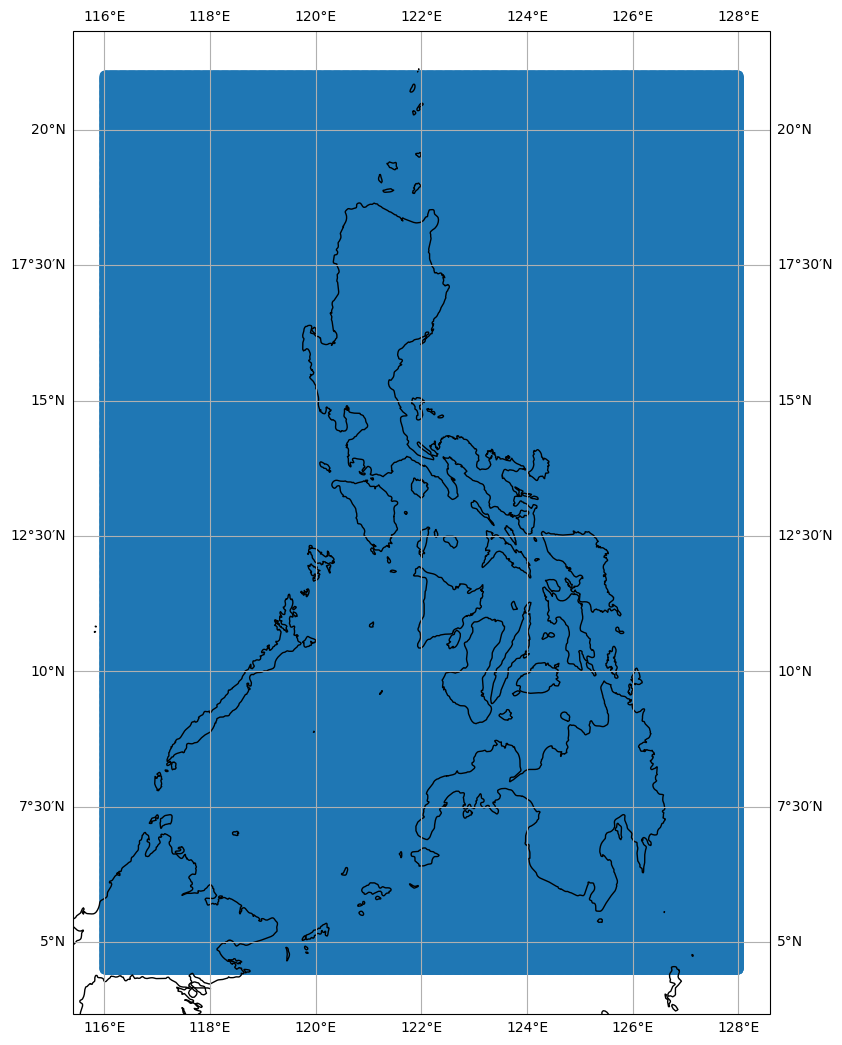

In [27]:
# Step 1: Define centroids for the entire Philippines
min_lat, max_lat, min_lon, max_lon = 4.5, 21.0, 116.0, 128.0  # Approximate bounds for the Philippines
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.01)
cent.plot()

In [28]:
# Step 2: Load exposure data
import geopandas as gdf
exp_lp = gdf.read_file("Random_Exposure_PHL_withValue.shp")
exp_lp = Exposures(exp_lp)
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
print(exp_lp)

description: None
ref_year: 2018
value_unit: USD
crs: EPSG:4326
data: (1000 entries)
     rand_point iso3        status color_code         name continent  \
0           0.0  PHL  Member State        PHL  Philippines      Asia   
1           1.0  PHL  Member State        PHL  Philippines      Asia   
2           2.0  PHL  Member State        PHL  Philippines      Asia   
3           3.0  PHL  Member State        PHL  Philippines      Asia   
996       996.0  PHL  Member State        PHL  Philippines      Asia   
997       997.0  PHL  Member State        PHL  Philippines      Asia   
998       998.0  PHL  Member State        PHL  Philippines      Asia   
999       999.0  PHL  Member State        PHL  Philippines      Asia   

                 region iso_3166_1   french_sho ExposureVa    value  \
0    South-Eastern Asia         PH  Philippines       None  10000.0   
1    South-Eastern Asia         PH  Philippines       None  10000.0   
2    South-Eastern Asia         PH  Philippines      

In [29]:
# Define the impact function using calibrated regional set
haz_type = "TC"
imp_fun_set_TC = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
impf_phl = imp_fun_set_TC.get_func(haz_type="TC", fun_id=7)

impf_pnt = ImpactFuncSet()
impf_pnt.append(impf_phl)
impf_pnt.check()

# Assign impact function ID to exposures
haz_id = 7
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
exp_lp.gdf.rename(columns={"impf_": f"impf_{haz_type}"}, inplace=True)
exp_lp.gdf[f"impf_{haz_type}"] = haz_id
exp_lp.check()

In [30]:
# List to collect results
results = []

csv_files = glob.glob("./WindGustCSV/max_wind_gust_*.csv")

# Process each CSV file
for file in csv_files:
    # Extract SID from filename
    sid = file.split('_')[-1].replace('.csv', '')

    # Load wind gust data from CSV
    wind_gust_df = pd.read_csv(file)

    # Assume CSV has columns 'latitude', 'longitude', 'max_wind_gust'
    wind_gust_points = wind_gust_df[['latitude', 'longitude']].values
    wind_gust_values = wind_gust_df['max_wind_gust'].values  # Assumed in m/s

    # Interpolate wind gust data to centroids
    cent_coords = np.stack([cent.lat, cent.lon], axis=1)

    wind_gust_interp = griddata(
        wind_gust_points,
        wind_gust_values,
        cent_coords,
        method='nearest'
    )

    # Verify interpolated data shape
    n_centroids = cent.size
    if wind_gust_interp.shape[0] != n_centroids:
        raise ValueError(f"Interpolated wind gust data size ({wind_gust_interp.shape[0]}) does not match number of centroids ({n_centroids}).")

    # Create TropCyclone hazard
    tc_pnt = TropCyclone()
    tc_pnt.centroids = cent
    tc_pnt.event_id = np.array([1])  # Single event
    tc_pnt.event_name = [sid]
    tc_pnt.frequency = np.array([1.0])  # Assuming one event
    tc_pnt.haz_type = 'TC'

    # Initialize intensity sparse matrix (n_events x n_centroids)
    tc_pnt.intensity = csr_matrix((1, n_centroids), dtype=np.float64)
    tc_pnt.intensity[0, :] = wind_gust_interp

    # Initialize fraction sparse matrix
    fraction_data = (wind_gust_interp > 0).astype(np.float64)
    tc_pnt.fraction = csr_matrix(fraction_data.reshape(1, n_centroids), dtype=np.float64)

    tc_pnt.check()

    # Compute economic impact
    imp_pnt = ImpactCalc(exp_lp, impf_pnt, tc_pnt).impact(save_mat=True)

    # Print the total economic impact for this event
    print(f"For event {sid}: Total Economic Impact (USD): {imp_pnt.aai_agg:,.2f}")

    # Collect result
    results.append({'TC_Event_No': sid, 'Total_Economic_Impact_USD': imp_pnt.aai_agg})

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 2009123N10111: Total Economic Impact (USD): 0.01


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 2009270N10148: Total Economic Impact (USD): 1.69


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


...

For event 2006329N06150: Total Economic Impact (USD): 59.65


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 1990310N07152: Total Economic Impact (USD): 85.20


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 2001170N11138: Total Economic Impact (USD): 0.00


In [31]:
# Save all results to CSV
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='TC_Event_No')
results_df.to_csv('11_all_tc_Total_Economic_Impact_USD.csv', index=False)
print("All results saved to '11_all_tc_Total_Economic_Impact_USD.csv'")

All results saved to '11_all_tc_Total_Economic_Impact_USD.csv'


In [32]:
# Calculate average economic impact per year
results_df['Year'] = results_df['TC_Event_No'].str[:4].astype(int)
yearly_avg = results_df.groupby('Year')['Total_Economic_Impact_USD'].mean().reset_index()
yearly_avg.columns = ['Year', 'Average_Economic_Impact_USD']
yearly_avg.to_csv('11_yearly_average_impacts.csv', index=False)
print("Yearly average impacts saved to '11_yearly_average_impacts.csv'")

Yearly average impacts saved to '11_yearly_average_impacts.csv'


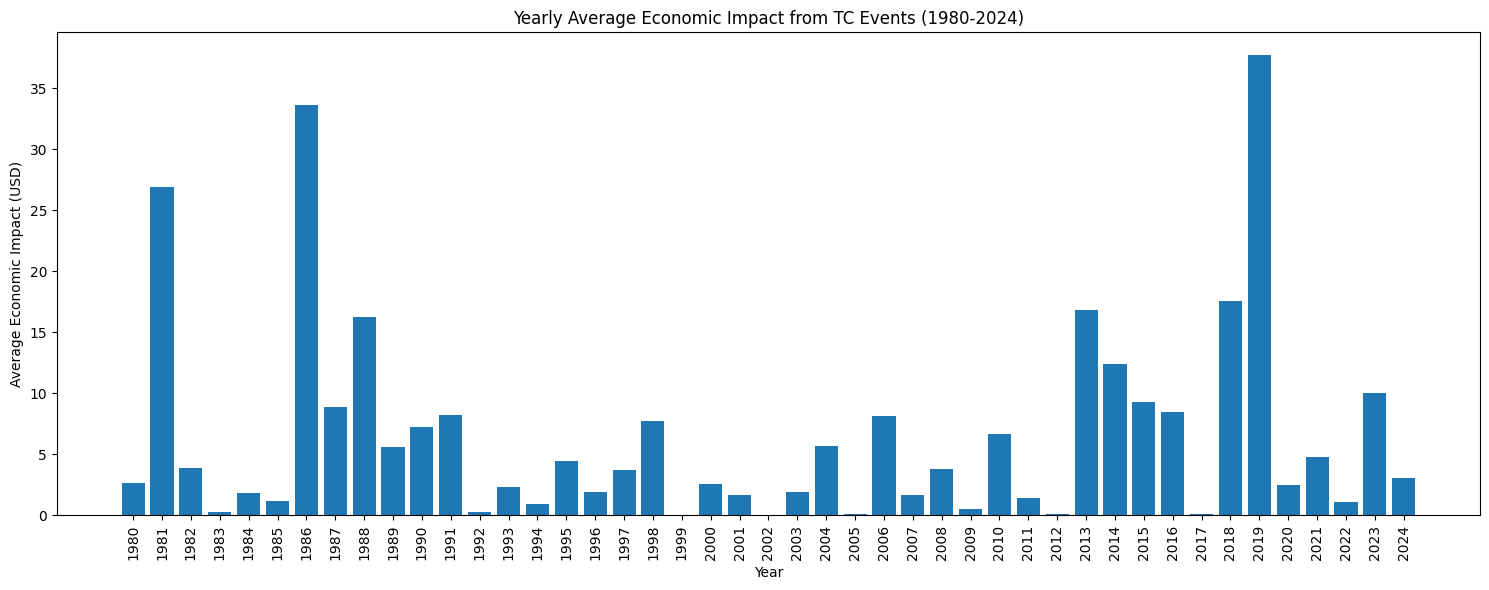

In [33]:
# Plot the yearly average from 1980 to 2024, filling missing years with 0
all_years = pd.DataFrame({'Year': range(1980, 2025)})
yearly_avg = all_years.merge(yearly_avg, on='Year', how='left').fillna(0)

plt.figure(figsize=(15, 6))
plt.bar(yearly_avg['Year'], yearly_avg['Average_Economic_Impact_USD'])
plt.xlabel('Year')
plt.ylabel('Average Economic Impact (USD)')
plt.title('Yearly Average Economic Impact from TC Events (1980-2024)')
plt.xticks(range(1980, 2025), rotation=90)
plt.tight_layout()
plt.show()

# **1.2 Using Random Exposure Data + CASE 4 + ERA5LAND Wind Gust CSV to find the annual average impact**

In [8]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.interpolate import griddata
from scipy.sparse import csr_matrix
import os
from climada.entity import Exposures, ImpactFuncSet, IFTropCyclone, ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet, ImpfTropCyclone
from climada.hazard import Centroids, TCTracks, TropCyclone
from climada.engine import ImpactCalc
from climada.engine import Impact
from climada.entity import LitPop
from climada.entity.impact_funcs.trop_cyclone import ImpfSetTropCyclone
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


<GeoAxes: >

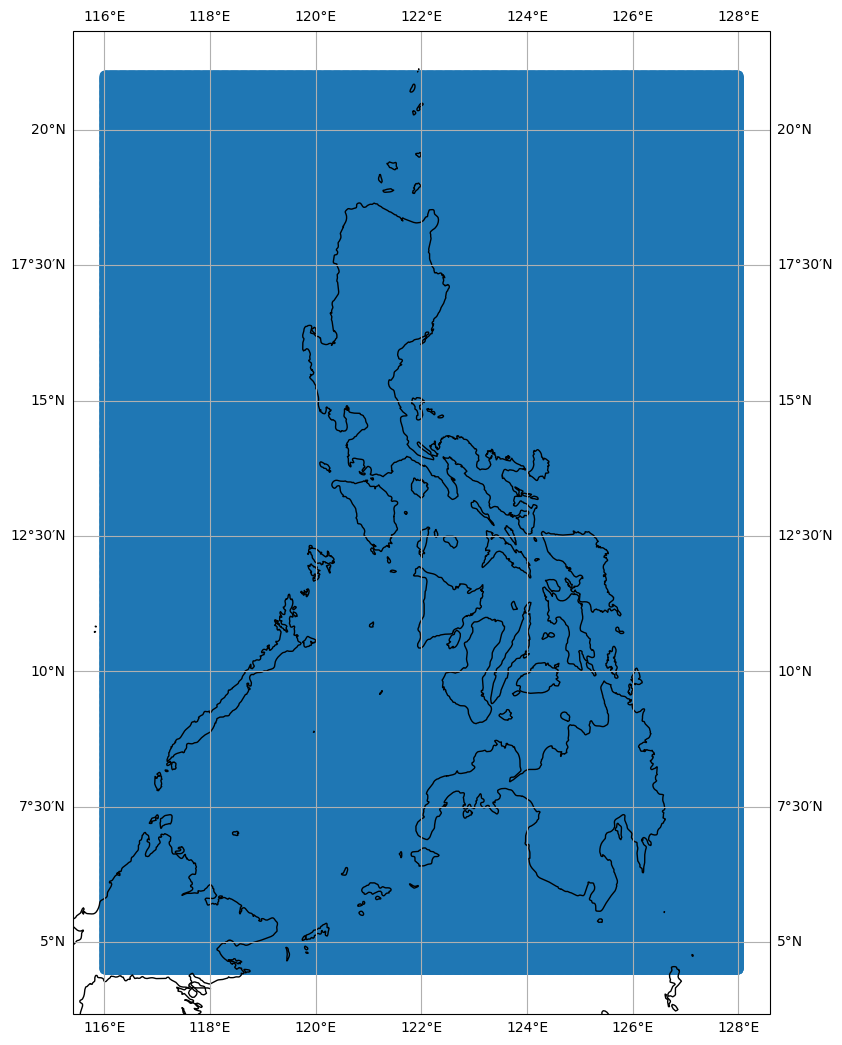

In [6]:
# Step 1: Define centroids for the entire Philippines
min_lat, max_lat, min_lon, max_lon = 4.5, 21.0, 116.0, 128.0  # Approximate bounds for the Philippines
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.01)
cent.plot()

In [7]:
# Step 2: Load exposure data
import geopandas as gdf
exp_lp = gdf.read_file("Random_Exposure_PHL_withValue.shp")
exp_lp = Exposures(exp_lp)
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
print(exp_lp)

description: None
ref_year: 2018
value_unit: USD
crs: EPSG:4326
data: (1000 entries)
     rand_point iso3        status color_code         name continent  \
0           0.0  PHL  Member State        PHL  Philippines      Asia   
1           1.0  PHL  Member State        PHL  Philippines      Asia   
2           2.0  PHL  Member State        PHL  Philippines      Asia   
3           3.0  PHL  Member State        PHL  Philippines      Asia   
996       996.0  PHL  Member State        PHL  Philippines      Asia   
997       997.0  PHL  Member State        PHL  Philippines      Asia   
998       998.0  PHL  Member State        PHL  Philippines      Asia   
999       999.0  PHL  Member State        PHL  Philippines      Asia   

                 region iso_3166_1   french_sho ExposureVa    value  \
0    South-Eastern Asia         PH  Philippines       None  10000.0   
1    South-Eastern Asia         PH  Philippines       None  10000.0   
2    South-Eastern Asia         PH  Philippines      

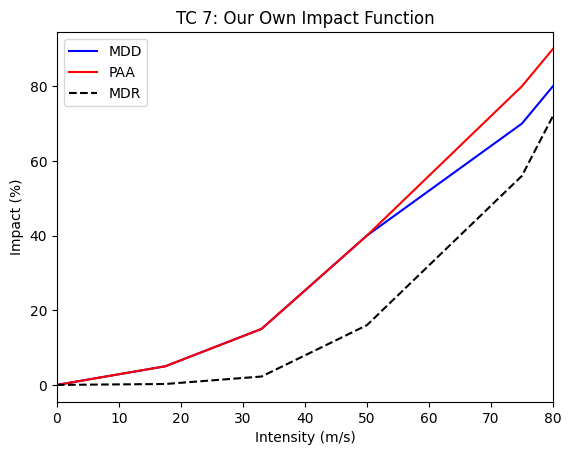

In [11]:
# Step 3: Define impact function for tropical cyclone
haz_type = "TC"
id = 7
name = "Our Own Impact Function"
# provide unit of the hazard intensity
intensity_unit= "m/s"

intensity = np.array([0, 17.5, 33, 50, 75, 80])
mdd = np.array([0, 0.05, 0.15, 0.4, 0.7, 0.8])
paa = np.array([0, 0.05, 0.15, 0.4, 0.8, 0.9])

impf_phl = ImpactFunc(
    id=id,
    name=name,
    intensity_unit=intensity_unit,
    haz_type=haz_type,
    intensity=intensity,
    mdd=mdd,
    paa=paa,
)
impf_pnt = ImpactFuncSet()
impf_pnt.append(impf_phl)
# check if the all the attributes are set correctly
impf_pnt.check()
# plot impact function
impf_pnt.plot();

# Assign impact function ID to exposures
exp_lp.gdf[f"impf_{haz_type}"] = id
exp_lp.check()

# **2.1 Finding Total Economic Impact of all TC Event and Average Impact per TC Event**
Recommend skip this part to 2.2 as it costs 45 mins

In [14]:
# Step 4: Initialize lists to store results
all_impacts = []
total_aai_agg = 0
event_impacts = []
total_eai_exp_sum = 0
total_value_affected = 0

# Step 5: Process all CSV files
import glob

csv_files = glob.glob("./WindGustCSV/max_wind_gust_*.csv")
for csv_file in csv_files:
    # Extract SID from filename
    sid = os.path.basename(csv_file).replace("max_wind_gust_", "").replace(".csv", "")

    # Load wind gust data
    wind_gust_df = pd.read_csv(csv_file)
    wind_gust_points = wind_gust_df[['latitude', 'longitude']].values
    wind_gust_values = wind_gust_df['max_wind_gust'].values  # Assumed in m/s

    # Interpolate wind gust data to centroids
    cent_coords = np.stack([cent.lat, cent.lon], axis=1)
    wind_gust_interp = griddata(
        wind_gust_points,
        wind_gust_values,
        cent_coords,
        method='nearest'
    )

    # Verify interpolated data
    n_centroids = cent.size
    if wind_gust_interp.shape[0] != n_centroids:
        print(f"Warning: Interpolated data size mismatch for {csv_file}")
        continue

    # Create TropCyclone hazard
    tc_pnt = TropCyclone()
    tc_pnt.centroids = cent
    tc_pnt.event_id = np.array([1])
    tc_pnt.event_name = [sid]
    tc_pnt.frequency = np.array([1.0])
    tc_pnt.haz_type = haz_type
    tc_pnt.intensity = csr_matrix((1, n_centroids), dtype=np.float64)
    tc_pnt.intensity[0, :] = wind_gust_interp
    tc_pnt.fraction = csr_matrix((wind_gust_interp > 0).astype(np.float64).reshape(1, n_centroids), dtype=np.float64)
    tc_pnt.check()

    # Compute economic impact
    imp_pnt = ImpactCalc(exp_lp, impf_pnt, tc_pnt).impact(save_mat=True)

    # Store results
    all_impacts.append(imp_pnt)
    total_aai_agg += imp_pnt.aai_agg
    event_impacts.append(imp_pnt.at_event[0])
    total_eai_exp_sum += imp_pnt.eai_exp.sum()
    total_value_affected += imp_pnt.tot_value.sum()


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


2025-08-11 02:42:47,208 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


2025-08-11 02:42:55,585 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


...

2025-08-11 03:28:08,442 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


2025-08-11 03:28:15,331 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


2025-08-11 03:28:20,609 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


In [15]:
# Step 6: Output aggregated results
print(f"Number of events processed: {len(all_impacts)}")
print(f"Total Economic Impact (AAI, USD): {total_aai_agg:,.2f}")
print(f"Average Impact per Event (USD): {np.mean(event_impacts):,.2f}")
print(f"Sum of Direct Impacts at All Exposure Points (USD): {total_eai_exp_sum:,.2f}")
print(f"Total Exposure Value Affected (USD): {total_value_affected:,.2f}")


Number of events processed: 445
Total Economic Impact (AAI, USD): 3,301,585.04
Average Impact per Event (USD): 7,419.29
Sum of Direct Impacts at All Exposure Points (USD): 3,301,585.04
Total Exposure Value Affected (USD): 4,450,000,000.00


# **2.2 Find the Total Economic Impact of each TC event and save it as a csv**

In [16]:
# List to collect results
results = []

# Process each CSV file
for file in csv_files:
    # Extract SID from filename
    sid = file.split('_')[-1].replace('.csv', '')

    # Load wind gust data from CSV
    wind_gust_df = pd.read_csv(file)

    # Assume CSV has columns 'latitude', 'longitude', 'max_wind_gust'
    wind_gust_points = wind_gust_df[['latitude', 'longitude']].values
    wind_gust_values = wind_gust_df['max_wind_gust'].values  # Assumed in m/s

    # Interpolate wind gust data to centroids
    cent_coords = np.stack([cent.lat, cent.lon], axis=1)

    wind_gust_interp = griddata(
        wind_gust_points,
        wind_gust_values,
        cent_coords,
        method='nearest'
    )

    # Verify interpolated data shape
    n_centroids = cent.size
    if wind_gust_interp.shape[0] != n_centroids:
        raise ValueError(f"Interpolated wind gust data size ({wind_gust_interp.shape[0]}) does not match number of centroids ({n_centroids}).")

    # Create TropCyclone hazard
    tc_pnt = TropCyclone()
    tc_pnt.centroids = cent
    tc_pnt.event_id = np.array([1])  # Single event
    tc_pnt.event_name = [sid]
    tc_pnt.frequency = np.array([1.0])  # Assuming one event
    tc_pnt.haz_type = 'TC'

    # Initialize intensity sparse matrix (n_events x n_centroids)
    tc_pnt.intensity = csr_matrix((1, n_centroids), dtype=np.float64)
    tc_pnt.intensity[0, :] = wind_gust_interp

    # Initialize fraction sparse matrix
    fraction_data = (wind_gust_interp > 0).astype(np.float64)
    tc_pnt.fraction = csr_matrix(fraction_data.reshape(1, n_centroids), dtype=np.float64)

    tc_pnt.check()

    # Compute economic impact
    imp_pnt = ImpactCalc(exp_lp, impf_pnt, tc_pnt).impact(save_mat=True)

    # Print the total economic impact for this event
    print(f"For event {sid}: Total Economic Impact (USD): {imp_pnt.aai_agg:,.2f}")

    # Collect result
    results.append({'TC_Event_No': sid, 'Total_Economic_Impact_USD': imp_pnt.aai_agg})

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 2009123N10111: Total Economic Impact (USD): 5,512.87


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 2009270N10148: Total Economic Impact (USD): 10,584.98


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


...

For event 2006329N06150: Total Economic Impact (USD): 23,754.34


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 1990310N07152: Total Economic Impact (USD): 37,163.85


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


For event 2001170N11138: Total Economic Impact (USD): 4,881.01


In [20]:
# Save all results to CSV
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='TC_Event_No')
results_df.to_csv('all_tc_Total_Economic_Impact_USD.csv', index=False)
print("All results saved to 'all_tc_Total_Economic_Impact_USD.csv'")

All results saved to 'all_tc_Total_Economic_Impact_USD.csv'


In [21]:
print(results_df)

       TC_Event_No  Total_Economic_Impact_USD
416  1980076N06148                8007.591676
113  1980126N08150                6108.962023
379  1980137N04158                5127.708405
272  1980171N06142                5047.047089
365  1980181N10130                7142.901143
..             ...                        ...
318  2024293N13141               15268.656691
212  2024308N08140                3433.346425
126  2024313N10169               12793.343854
19   2024313N15138                4764.085515
308  2024314N07151                4045.224561

[445 rows x 2 columns]


In [22]:
# Calculate average economic impact per year
results_df['Year'] = results_df['TC_Event_No'].str[:4].astype(int)
yearly_avg = results_df.groupby('Year')['Total_Economic_Impact_USD'].mean().reset_index()
yearly_avg.columns = ['Year', 'Average_Economic_Impact_USD']
yearly_avg.to_csv('yearly_average_impacts.csv', index=False)
print("Yearly average impacts saved to 'yearly_average_impacts.csv'")

Yearly average impacts saved to 'yearly_average_impacts.csv'


In [ ]:
yearly_avg

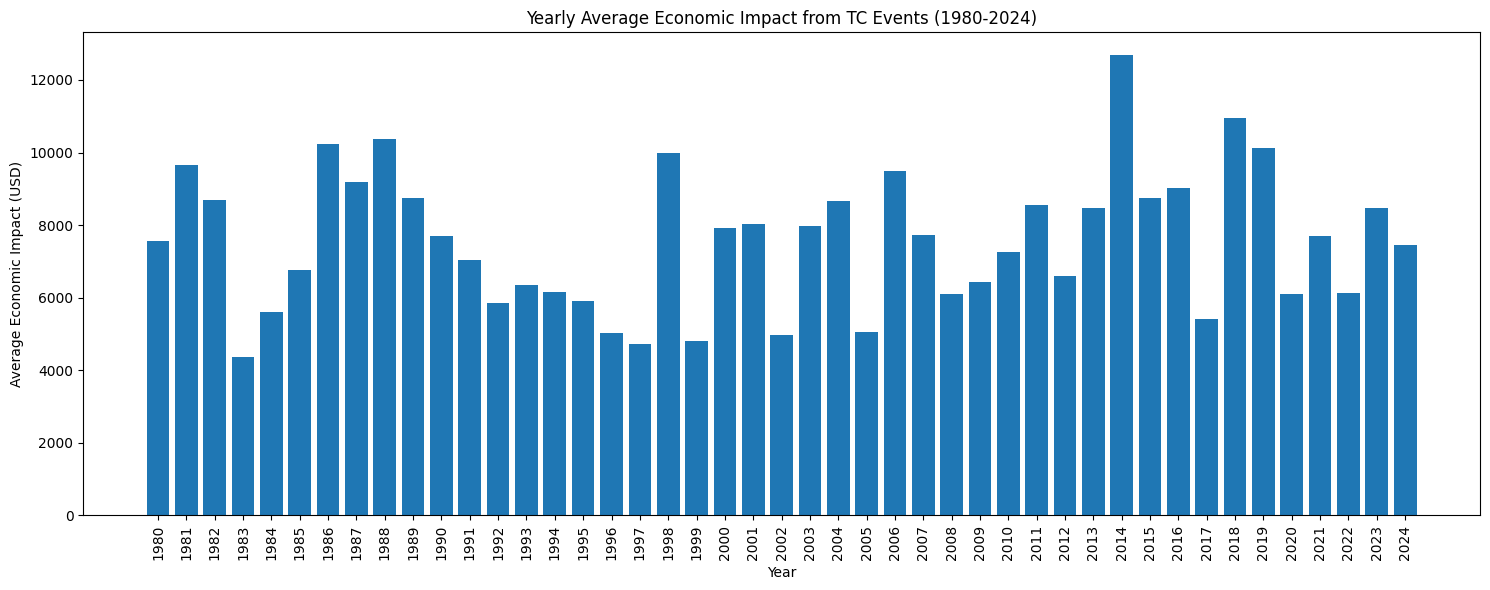

In [25]:
# Plot the yearly average from 1980 to 2024, filling missing years with 0
all_years = pd.DataFrame({'Year': range(1980, 2025)})
yearly_avg = all_years.merge(yearly_avg, on='Year', how='left').fillna(0)

plt.figure(figsize=(15, 6))
plt.bar(yearly_avg['Year'], yearly_avg['Average_Economic_Impact_USD'])
plt.xlabel('Year')
plt.ylabel('Average Economic Impact (USD)')
plt.title('Yearly Average Economic Impact from TC Events (1980-2024)')
plt.xticks(range(1980, 2025), rotation=90)
plt.tight_layout()
plt.show()

# **3 Test a ERA5LAND CSV into 1.1**

the results of 1.1 seems too low, so here i test one of it to see the resuls

<GeoAxes: >

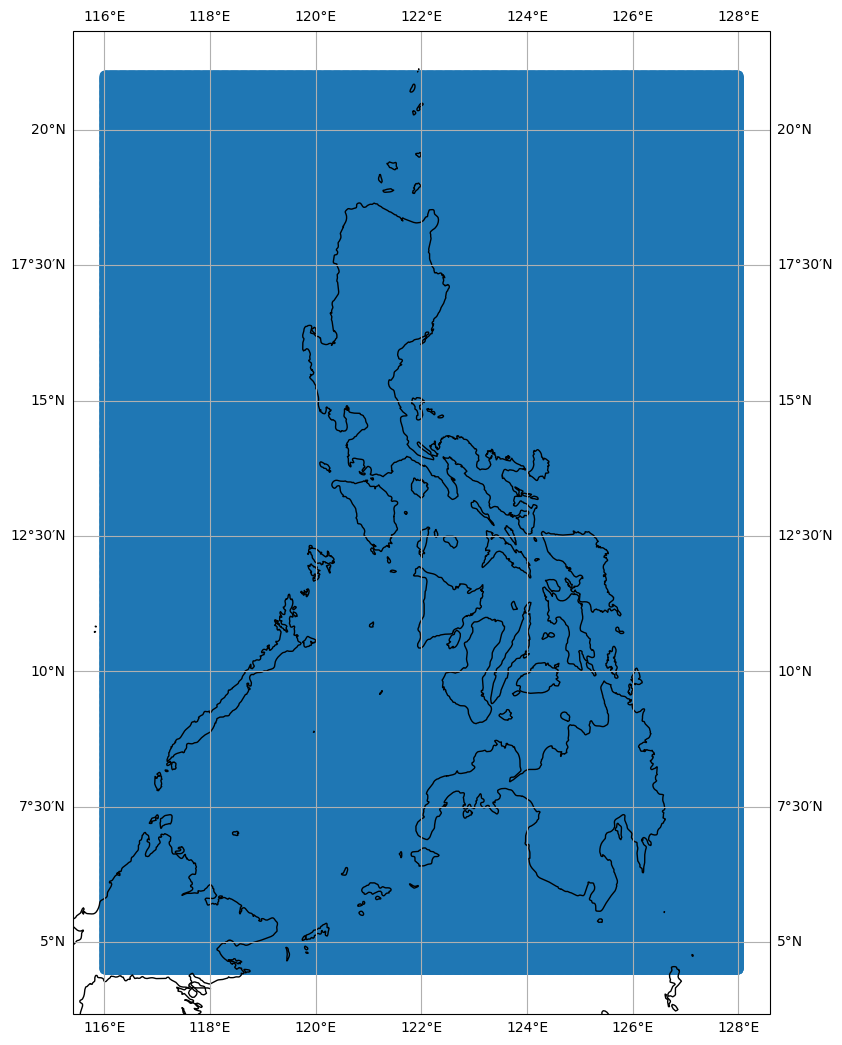

In [34]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.interpolate import griddata
from scipy.sparse import csr_matrix
import os
from climada.entity import Exposures, ImpactFuncSet, IFTropCyclone, ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet, ImpfTropCyclone
from climada.hazard import Centroids, TCTracks, TropCyclone
from climada.engine import ImpactCalc
from climada.engine import Impact
from climada.entity import LitPop
from climada.entity.impact_funcs.trop_cyclone import ImpfSetTropCyclone
import matplotlib.pyplot as plt

# Step 1: Define centroids for the entire Philippines
min_lat, max_lat, min_lon, max_lon = 4.5, 21.0, 116.0, 128.0  # Approximate bounds for the Philippines
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.01)
cent.plot()

In [35]:
# Step 2: Load exposure data
import geopandas as gdf
exp_lp = gdf.read_file("Random_Exposure_PHL_withValue.shp")
exp_lp = Exposures(exp_lp)
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
print(exp_lp)

description: None
ref_year: 2018
value_unit: USD
crs: EPSG:4326
data: (1000 entries)
     rand_point iso3        status color_code         name continent  \
0           0.0  PHL  Member State        PHL  Philippines      Asia   
1           1.0  PHL  Member State        PHL  Philippines      Asia   
2           2.0  PHL  Member State        PHL  Philippines      Asia   
3           3.0  PHL  Member State        PHL  Philippines      Asia   
996       996.0  PHL  Member State        PHL  Philippines      Asia   
997       997.0  PHL  Member State        PHL  Philippines      Asia   
998       998.0  PHL  Member State        PHL  Philippines      Asia   
999       999.0  PHL  Member State        PHL  Philippines      Asia   

                 region iso_3166_1   french_sho ExposureVa    value  \
0    South-Eastern Asia         PH  Philippines       None  10000.0   
1    South-Eastern Asia         PH  Philippines       None  10000.0   
2    South-Eastern Asia         PH  Philippines      

In [36]:
# Define the impact function using calibrated regional set
haz_type = "TC"
imp_fun_set_TC = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
impf_phl = imp_fun_set_TC.get_func(haz_type="TC", fun_id=7)

impf_pnt = ImpactFuncSet()
impf_pnt.append(impf_phl)
impf_pnt.check()

# Assign impact function ID to exposures
haz_id = 7
exp_lp.gdf.rename(columns={"Exposure_1": "value"}, inplace=True)
exp_lp.gdf.rename(columns={"impf_": f"impf_{haz_type}"}, inplace=True)
exp_lp.gdf[f"impf_{haz_type}"] = haz_id
exp_lp.check()

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_populated_places_simple.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


For event 2021346N05145: Total Economic Impact (USD): 46.56


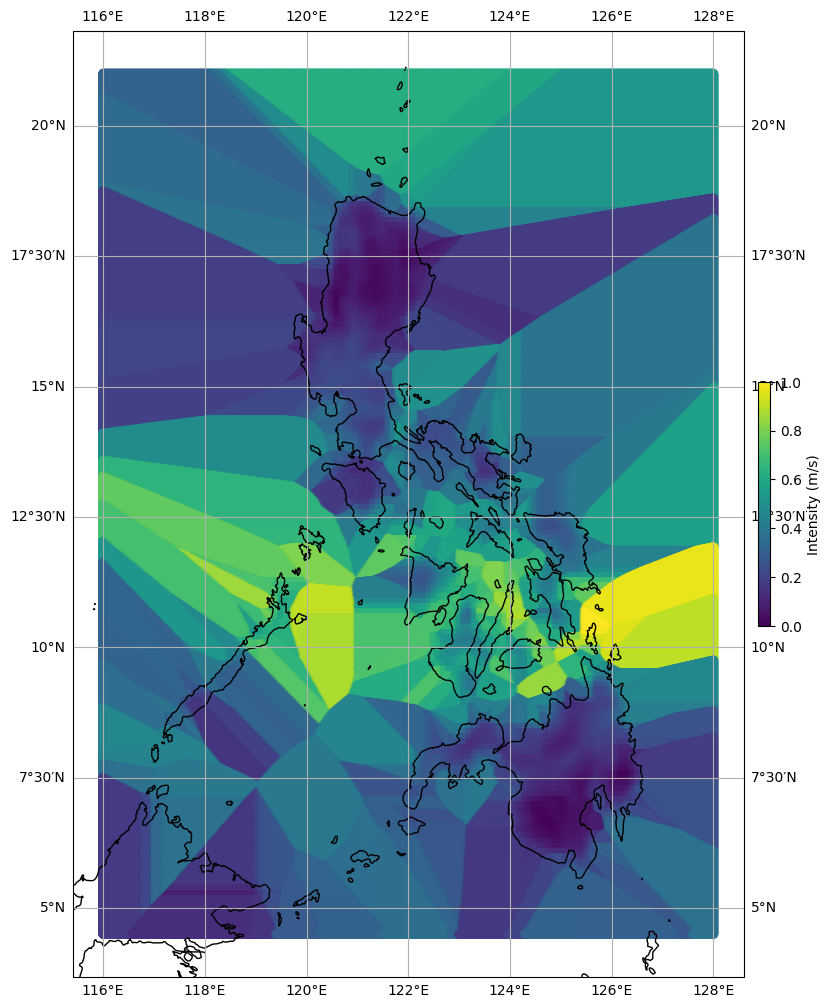

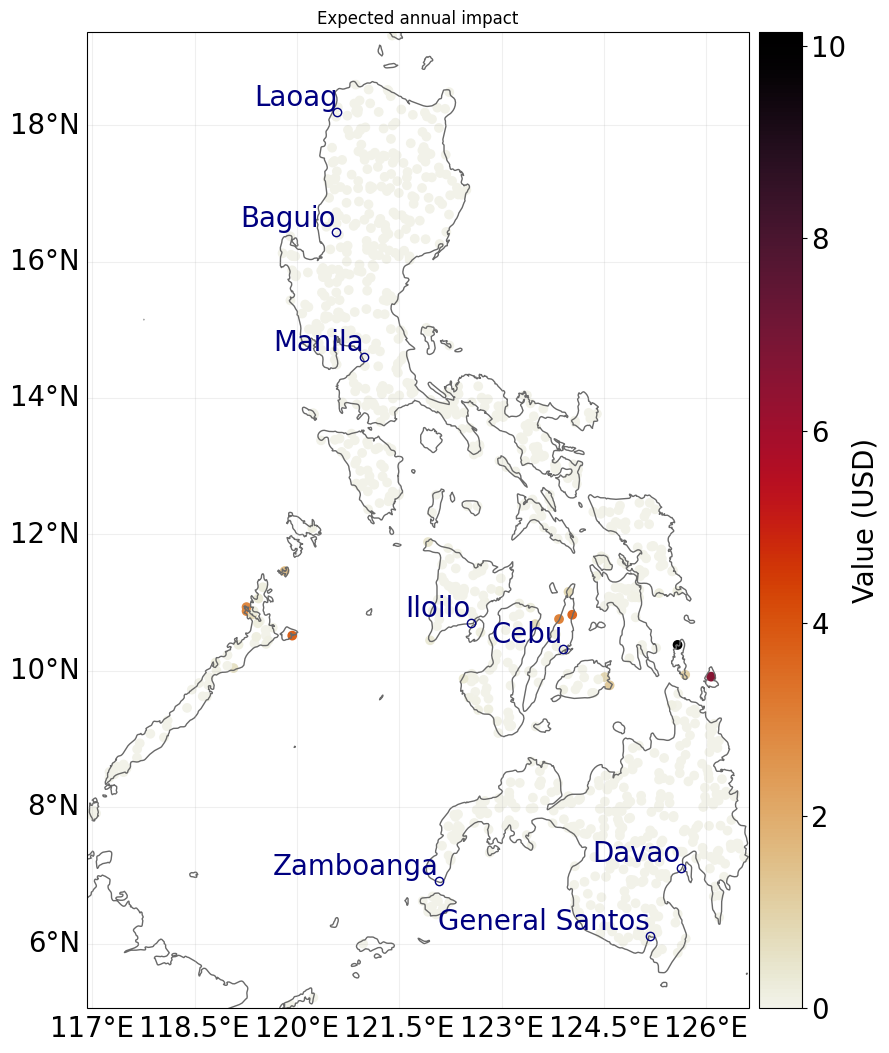

In [39]:
# Specify the single CSV file
csv_files = ["max_wind_gust_2021346N05145.csv"]

# List to collect results
results = []

# Process the CSV file
for file in csv_files:
    # Extract SID from filename
    sid = file.split('_')[-1].replace('.csv', '')

    # Load wind gust data from CSV
    wind_gust_df = pd.read_csv(file)

    # Assume CSV has columns 'latitude', 'longitude', 'max_wind_gust'
    wind_gust_points = wind_gust_df[['latitude', 'longitude']].values
    wind_gust_values = wind_gust_df['max_wind_gust'].values  # Assumed in m/s

    # Interpolate wind gust data to centroids
    cent_coords = np.stack([cent.lat, cent.lon], axis=1)

    wind_gust_interp = griddata(
        wind_gust_points,
        wind_gust_values,
        cent_coords,
        method='nearest'
    )

    # Verify interpolated data shape
    n_centroids = cent.size
    if wind_gust_interp.shape[0] != n_centroids:
        raise ValueError(f"Interpolated wind gust data size ({wind_gust_interp.shape[0]}) does not match number of centroids ({n_centroids}).")

    # Create TropCyclone hazard
    tc_pnt = TropCyclone()
    tc_pnt.centroids = cent
    tc_pnt.event_id = np.array([1])  # Single event
    tc_pnt.event_name = [sid]
    tc_pnt.frequency = np.array([1.0])  # Assuming one event
    tc_pnt.haz_type = 'TC'

    # Initialize intensity sparse matrix (n_events x n_centroids)
    tc_pnt.intensity = csr_matrix((1, n_centroids), dtype=np.float64)
    tc_pnt.intensity[0, :] = wind_gust_interp

    # Initialize fraction sparse matrix
    fraction_data = (wind_gust_interp > 0).astype(np.float64)
    tc_pnt.fraction = csr_matrix(fraction_data.reshape(1, n_centroids), dtype=np.float64)

    tc_pnt.check()

    ax_pnt = tc_pnt.centroids.plot(
    c=np.array(tc_pnt.intensity[0, :].todense()).squeeze()
    )  # plot intensity per point
    ax_pnt.get_figure().colorbar(
        ax_pnt.collections[0], fraction=0.0175, pad=0.02
    ).set_label(
        "Intensity (m/s)"
    )  # add colorbar


    # Compute economic impact
    imp_pnt = ImpactCalc(exp_lp, impf_pnt, tc_pnt).impact(save_mat=True)

    imp_pnt.plot_scatter_eai_exposure(ignore_zero=False, buffer=0.05);

    # Print the total economic impact for this event
    print(f"For event {sid}: Total Economic Impact (USD): {imp_pnt.aai_agg:,.2f}")

    # Collect result
    results.append({'TC_Event_No': sid, 'Total_Economic_Impact_USD': imp_pnt.aai_agg})